In [1]:
import seaborn as sns
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from torch.utils.data import TensorDataset, DataLoader

df = sns.load_dataset('iris')
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values.astype('float32')
y = df['species'].astype('category').cat.codes.values.astype('int64')
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, 3 classes")

Dataset: 150 samples, 4 features, 3 classes


In [2]:
def build_model():
    return nn.Sequential(
        nn.Linear(4, 16),
        nn.ReLU(),
        nn.Linear(16, 3)
    )

In [3]:
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []
fold_cms = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long()),
        batch_size=32, shuffle=True
    )

    model = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(100):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(torch.from_numpy(X_val)), dim=1).numpy()

    acc = (preds == y_val).mean()
    fold_accuracies.append(acc)
    fold_cms.append(confusion_matrix(y_val, preds))
    print(f"Fold {fold}: accuracy = {acc:.4f}")

print(f"\nMean: {np.mean(fold_accuracies):.4f}  Std: {np.std(fold_accuracies):.4f}")

Fold 1: accuracy = 1.0000
Fold 2: accuracy = 0.9667
Fold 3: accuracy = 0.9000
Fold 4: accuracy = 1.0000
Fold 5: accuracy = 1.0000

Mean: 0.9733  Std: 0.0389


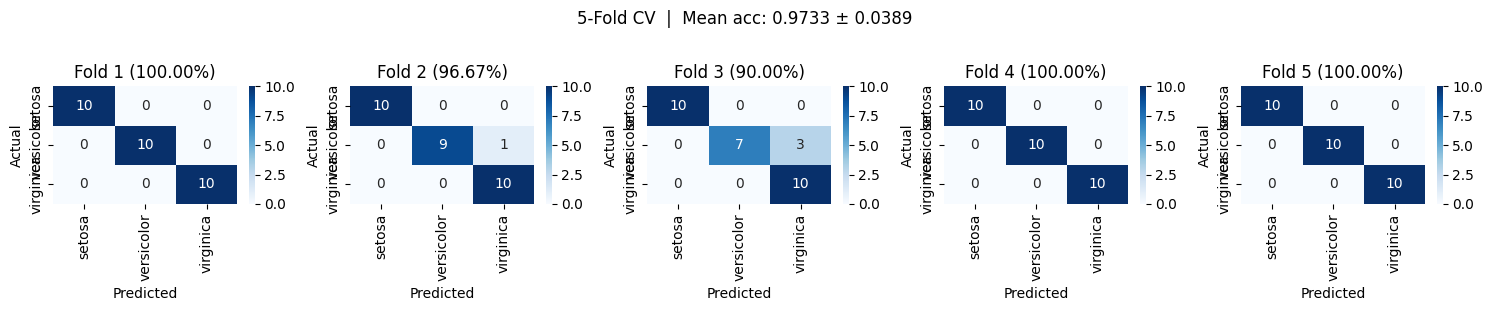

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['setosa', 'versicolor', 'virginica']
fig, axes = plt.subplots(1, k, figsize=(3 * k, 3))

for i, (cm, ax) in enumerate(zip(fold_cms, axes), 1):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(f'Fold {i} ({fold_accuracies[i-1]:.2%})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle(f'5-Fold CV  |  Mean acc: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}',
             y=1.02)
plt.tight_layout()
plt.show()